In [25]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gpx_io import parse_gpx_to_dataframe

def downsample_df(df, min_distance: float = 0.01) -> pd.DataFrame:
    out = []
    for _, row in df.iterrows():
        if len(out) == 0:
            out.append(row)
        else:
            last_row = out[-1]
            if row['distance_mi'] - last_row['distance_mi'] > min_distance:
                out.append(row)
    return pd.DataFrame(out).reset_index(drop=True)


def load_df(gpx_file_path: str, min_distance: float = 0.01) -> pd.DataFrame:
    df = parse_gpx_to_dataframe(gpx_file_path)
    df_imp = df.copy()
    df_imp['distance_mi'] = df_imp['distance_km'] * 0.621371
    df_imp['elevation_ft'] = df_imp['elevation_m'] * 3.28084
    if 'time' in df_imp.columns:
        df_imp['time'] = (df_imp['time'] - df_imp['time'].iloc[0]).dt.total_seconds()
        df_imp = df_imp[['distance_mi', 'elevation_ft', 'time']]
    else:
        df_imp = df_imp[['distance_mi', 'elevation_ft']]
    return downsample_df(df_imp, min_distance=min_distance)

metric_century = load_df('/Users/kkleidal/Downloads/First_Metric_Century.gpx')
metric_century

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,distance_mi,elevation_ft,time
0,0.000000,309.055128,0.0
1,0.011711,309.711296,7.0
2,0.022606,313.648304,13.0
3,0.034620,316.272976,18.0
4,0.045852,317.585312,22.0
...,...,...,...
5537,67.508195,305.774288,17194.0
5538,67.518957,310.367464,17198.0
5539,67.530696,314.304472,17203.0
5540,67.542383,318.897648,17209.0


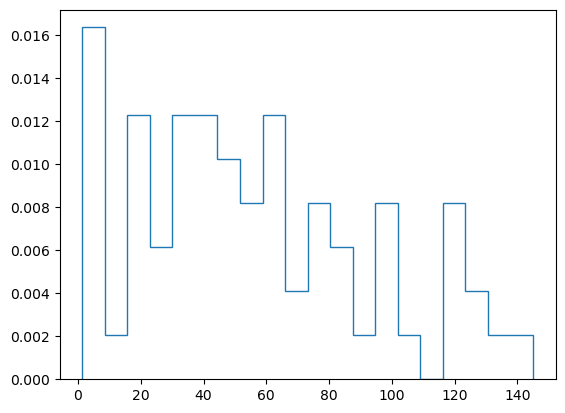

In [23]:
def get_elevation_per_mile_df(df: pd.DataFrame, distance_mi_step: float = 1) -> pd.DataFrame:
    # compute elevation delta:
    elevations = df['elevation_ft']
    elevation_delta = elevations.diff().fillna(0)
    out = []

    for start_distance_steps in range(int(np.floor(df['distance_mi'].min() / distance_mi_step)), int(np.ceil(df['distance_mi'].max() / distance_mi_step))):
        start_distance_mi = start_distance_steps * distance_mi_step
        end_distance_mi = start_distance_mi + distance_mi_step
        m = df['distance_mi'].between(start_distance_mi, end_distance_mi)
        sub_elevation_delta = elevation_delta[m]
        elevation_gain = sub_elevation_delta.clip(0).sum()
        elevation_delta_per_mile = elevation_gain / distance_mi_step
        out.append({
            'distance_mi': start_distance_mi,
            'elevation_delta_per_mile': elevation_delta_per_mile
        })
    return pd.DataFrame(out)

elevation_per_mile_df = get_elevation_per_mile_df(metric_century)
elevation_per_mile_df

plt.hist(elevation_per_mile_df['elevation_delta_per_mile'], bins=20, histtype='step', density=True)
plt.show()


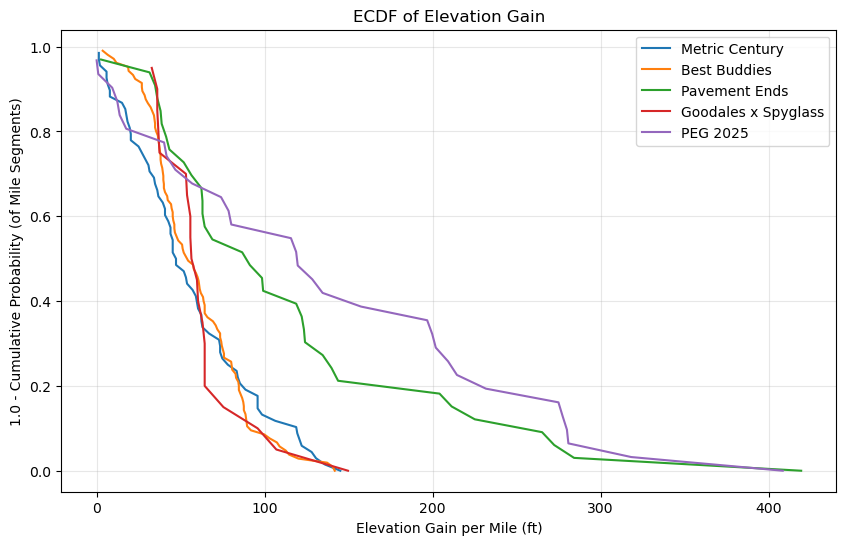

In [35]:
best_buddies = load_df('/Users/kkleidal/Downloads/2025_Best_Buddies_Challenge_Hyannisport_-_100M.gpx')
best_buddies_elevation_per_mile_df = get_elevation_per_mile_df(best_buddies)

peg = load_df('/Users/kkleidal/Downloads/Pavement_Ends_Short_Course.gpx')
peg_elevation_per_mile_df = get_elevation_per_mile_df(peg)

goodales_spyglass = load_df('/Users/kkleidal/Downloads/Goodales_x_Spyglass_Group_Ride.gpx')
goodales_spyglass_elevation_per_mile_df = get_elevation_per_mile_df(goodales_spyglass)

peg_2025 = get_elevation_per_mile_df(load_df('/Users/kkleidal/Downloads/2025 PEG- Light.gpx'))

# minn = 0
# maxx = max(elevation_per_mile_df['elevation_delta_per_mile'].max(), best_buddies_elevation_per_mile_df['elevation_delta_per_mile'].max(), peg_elevation_per_mile_df['elevation_delta_per_mile'].max())
# bins = np.linspace(minn, maxx + 1, 20)
# plt.hist(elevation_per_mile_df['elevation_delta_per_mile'], bins=bins, alpha=0.3, density=True, label='Metric Century')
# plt.hist(best_buddies_elevation_per_mile_df['elevation_delta_per_mile'], bins=bins, alpha=0.3, density=True, label='Best Buddies')
# plt.hist(peg_elevation_per_mile_df['elevation_delta_per_mile'], bins=bins, alpha=0.3, density=True, label='Pavement Ends')
# plt.legend()
# plt.show()

# ... existing code ...

# ECDF plots are excellent for comparing distributions
plt.figure(figsize=(10, 6))
for df, label in [
    (elevation_per_mile_df, 'Metric Century'),
    (best_buddies_elevation_per_mile_df, 'Best Buddies'),
    (peg_elevation_per_mile_df, 'Pavement Ends'),
    (goodales_spyglass_elevation_per_mile_df, 'Goodales x Spyglass'),
    (peg_2025, 'PEG 2025'),
]:
    # Sort values and calculate cumulative probability
    x = np.sort(df['elevation_delta_per_mile'].values)
    y = 1.0 - np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, '-', label=label)

plt.xlabel('Elevation Gain per Mile (ft)')
plt.ylabel('1.0 - Cumulative Probability (of Mile Segments)')
plt.title('ECDF of Elevation Gain')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# ... existing code ...

